In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("e-commerce-customers-behavior.csv")

In [4]:
df.head()

,Customer ID,Gender,Age,City,Membership Type,Total Spend,Items Purchased,Average Rating,Discount Applied,Days Since Last Purchase,Satisfaction Level
0,101,Female,29,New York,Gold,1120.20,14,4.6,True,25,Satisfied
1,102,Male,34,Los Angeles,Silver,780.50,11,4.1,False,18,Neutral
2,103,Female,43,Chicago,Bronze,510.75,9,3.4,True,42,Unsatisfied
3,104,Male,30,San Francisco,Gold,1480.30,19,4.7,False,12,Satisfied
4,105,Male,27,Miami,Silver,720.40,13,4.0,True,55,Unsatisfied


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer ID               350 non-null    int64  
 1   Gender                    350 non-null    object 
 2   Age                       350 non-null    int64  
 3   City                      350 non-null    object 
 4   Membership Type           350 non-null    object 
 5   Total Spend               350 non-null    float64
 6   Items Purchased           350 non-null    int64  
 7   Average Rating            350 non-null    float64
 8   Discount Applied          350 non-null    bool   
 9   Days Since Last Purchase  350 non-null    int64  
 10  Satisfaction Level        348 non-null    object 
dtypes: bool(1), float64(2), int64(4), object(4)
memory usage: 27.8+ KB


In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Customer ID,350.0,275.500000,101.180532,101.0,188.25,275.5,362.75,450.0
Age,350.0,33.597143,4.870882,26.0,30.00,32.5,37.00,43.0
Total Spend,350.0,845.381714,362.058695,410.8,502.00,775.2,1160.60,1520.1
Items Purchased,350.0,12.600000,4.155984,7.0,9.00,12.0,15.00,21.0
Average Rating,350.0,4.019143,0.580539,3.0,3.50,4.1,4.50,4.9
Days Since Last Purchase,350.0,26.588571,13.440813,9.0,15.00,23.0,38.00,63.0


In [8]:
df.isnull().sum()

Customer ID                 0
Gender                      0
Age                         0
City                        0
Membership Type             0
Total Spend                 0
Items Purchased             0
Average Rating              0
Discount Applied            0
Days Since Last Purchase    0
Satisfaction Level          2
dtype: int64

In [9]:
df.drop("Customer ID", axis = 1, inplace=True)

In [16]:
df.duplicated().sum()

np.int64(180)

In [12]:
df.dropna(inplace = True)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 348 entries, 0 to 349
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Gender                    348 non-null    object 
 1   Age                       348 non-null    int64  
 2   City                      348 non-null    object 
 3   Membership Type           348 non-null    object 
 4   Total Spend               348 non-null    float64
 5   Items Purchased           348 non-null    int64  
 6   Average Rating            348 non-null    float64
 7   Discount Applied          348 non-null    bool   
 8   Days Since Last Purchase  348 non-null    int64  
 9   Satisfaction Level        348 non-null    object 
dtypes: bool(1), float64(2), int64(3), object(4)
memory usage: 27.5+ KB


In [14]:
df.isnull().sum()

Gender                      0
Age                         0
City                        0
Membership Type             0
Total Spend                 0
Items Purchased             0
Average Rating              0
Discount Applied            0
Days Since Last Purchase    0
Satisfaction Level          0
dtype: int64

In [15]:
df["Gender"].value_counts()

Gender
Male      175
Female    173
Name: count, dtype: int64

In [17]:
df.head()

,Gender,Age,City,Membership Type,Total Spend,Items Purchased,Average Rating,Discount Applied,Days Since Last Purchase,Satisfaction Level
0,Female,29,New York,Gold,1120.20,14,4.6,True,25,Satisfied
1,Male,34,Los Angeles,Silver,780.50,11,4.1,False,18,Neutral
2,Female,43,Chicago,Bronze,510.75,9,3.4,True,42,Unsatisfied
3,Male,30,San Francisco,Gold,1480.30,19,4.7,False,12,Satisfied
4,Male,27,Miami,Silver,720.40,13,4.0,True,55,Unsatisfied


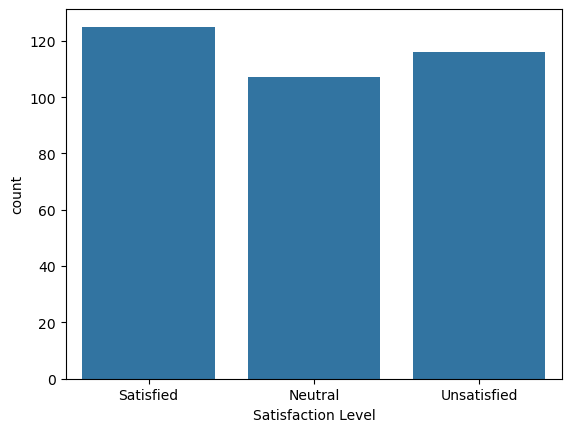

In [18]:
sns.countplot(data = df, x = "Satisfaction Level")
plt.show()

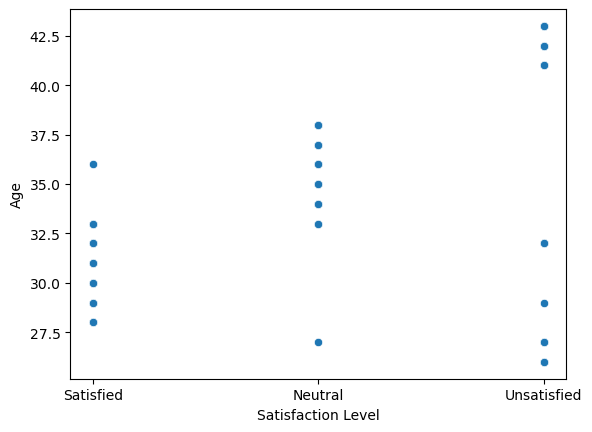

In [21]:
sns.scatterplot(data = df, x = "Satisfaction Level", y = "Age")
plt.show()

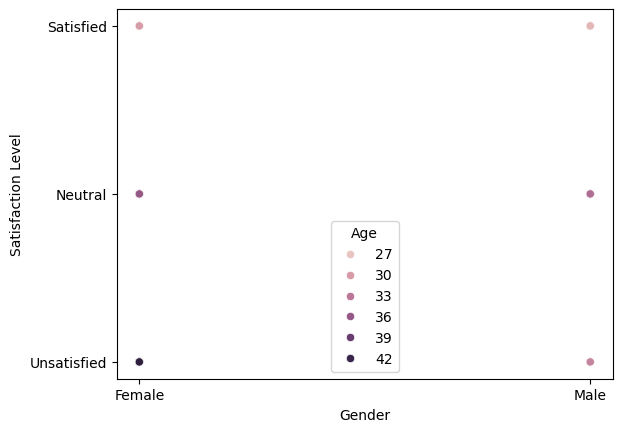

In [24]:
sns.scatterplot(data = df, x = "Gender", y = "Satisfaction Level", hue = "Age")
plt.show()

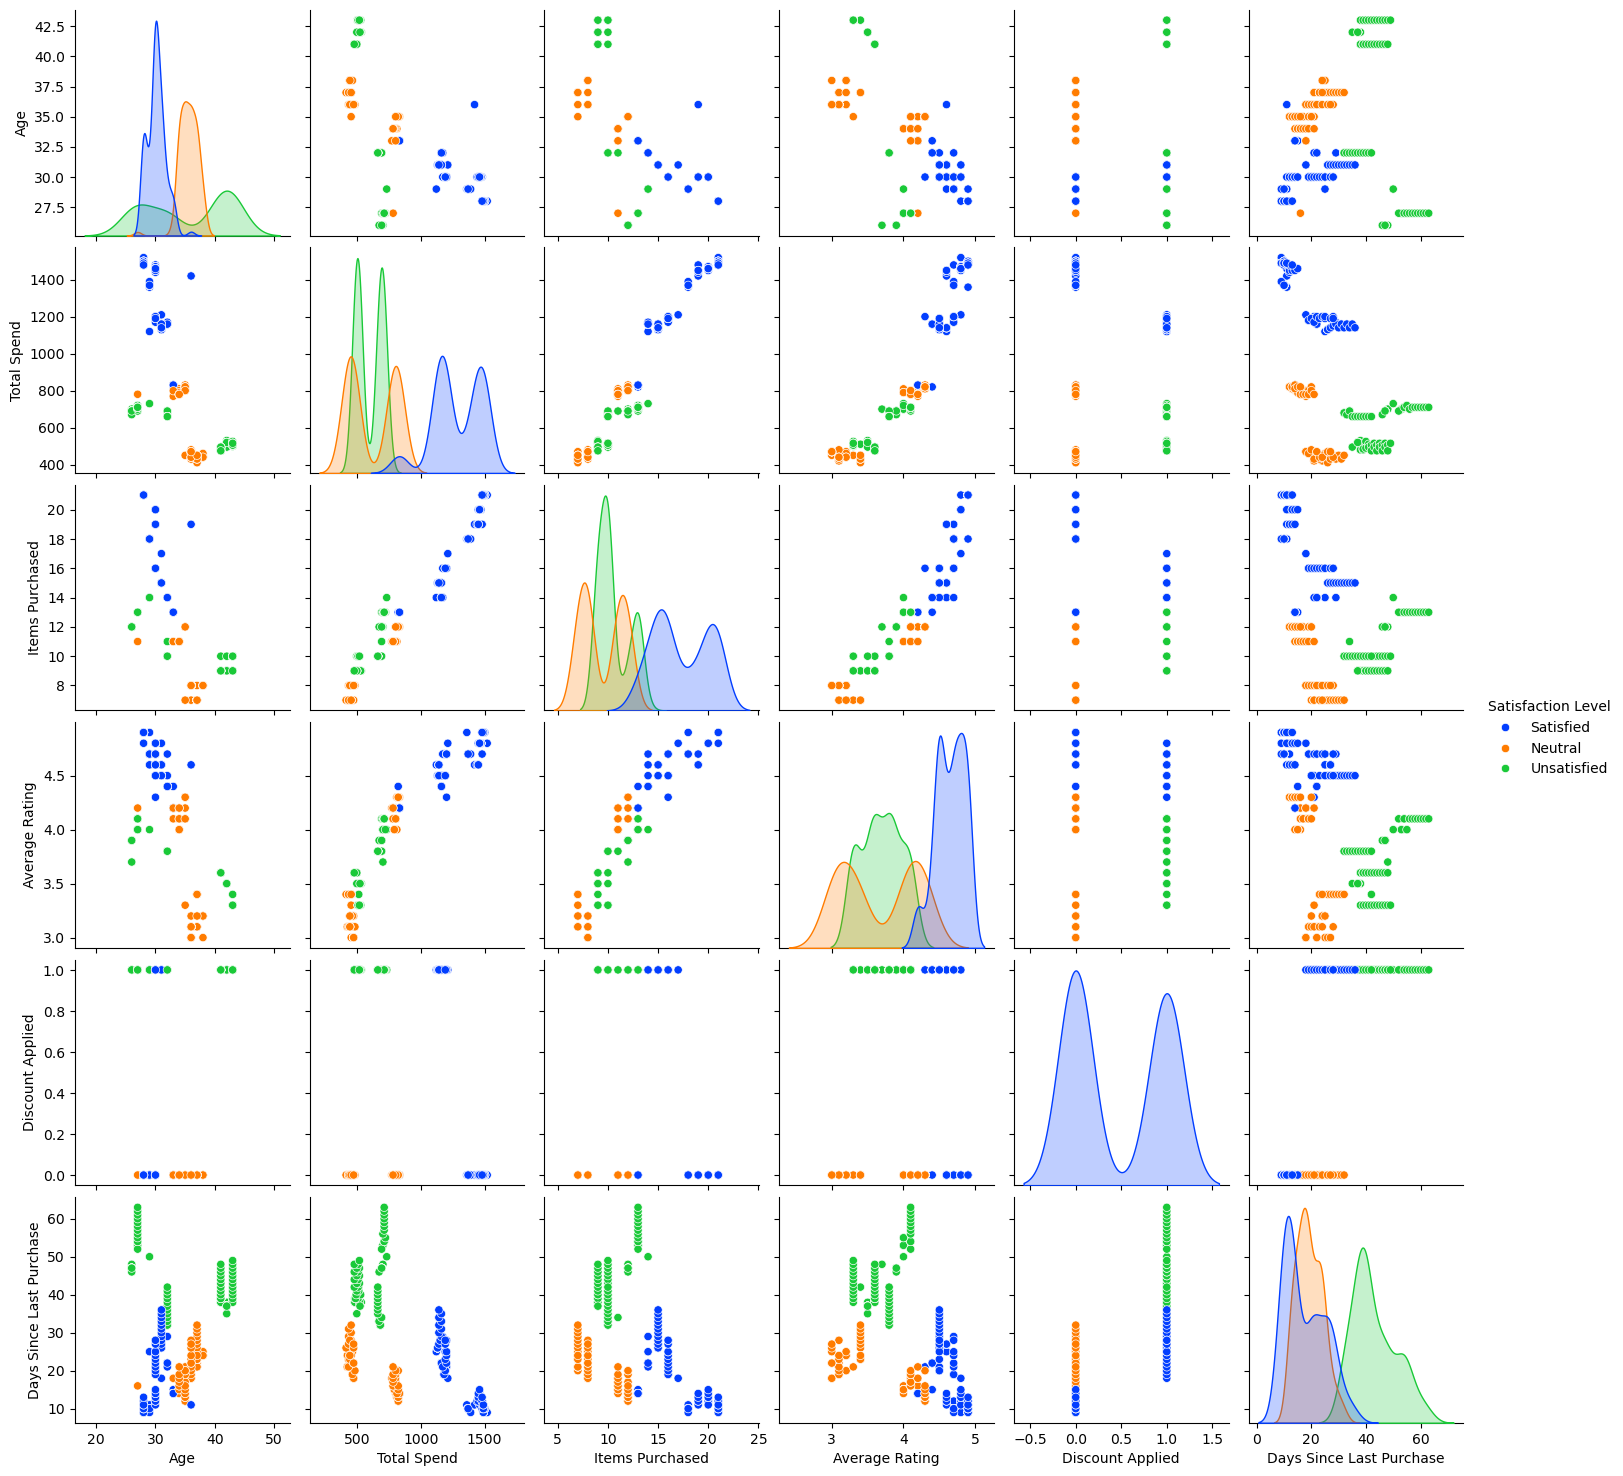

In [25]:
sns.pairplot(df, hue='Satisfaction Level', palette='bright', diag_kind='kde')
plt.show()

In [27]:
df.columns

Index(['Gender', 'Age', 'City', 'Membership Type', 'Total Spend',
       'Items Purchased', 'Average Rating', 'Discount Applied',
       'Days Since Last Purchase', 'Satisfaction Level'],
      dtype='object')

IndexError: index 3 is out of bounds for axis 0 with size 3

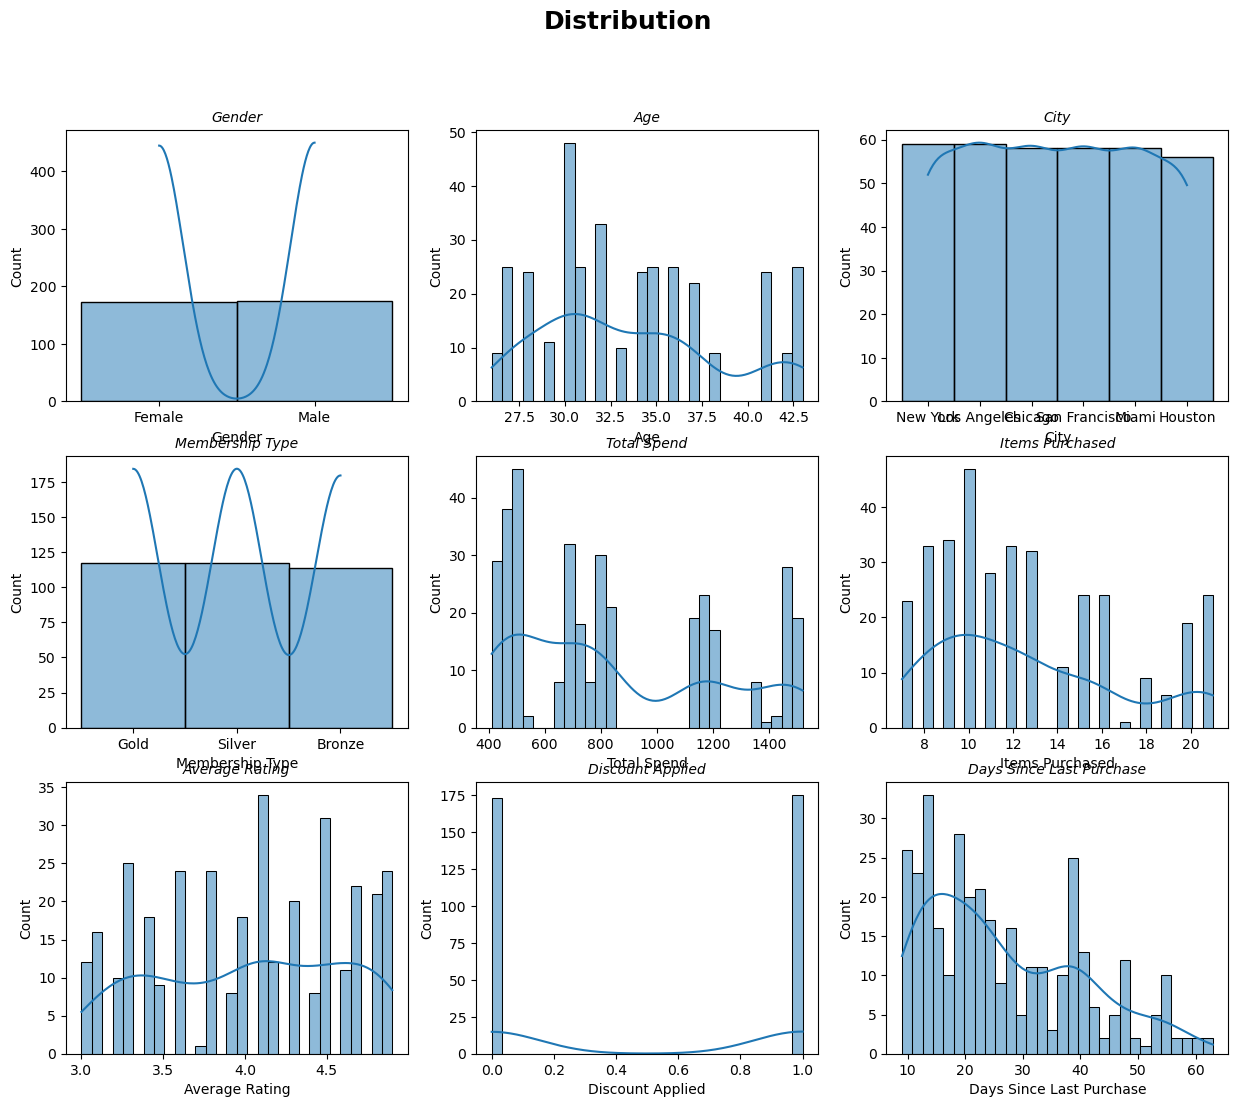

In [28]:
columns = ['Gender', 'Age', 'City', 'Membership Type', 'Total Spend',
       'Items Purchased', 'Average Rating', 'Discount Applied',
       'Days Since Last Purchase', 'Satisfaction Level']

fig, axes = plt.subplots(nrows = 3, ncols = 3, figsize = (15,12))
fig.suptitle("Distribution", fontsize = 18, fontweight = "bold")

for i, col in enumerate(columns):
    row = i // 3
    col_idx = i % 3
    ax = axes[row, col_idx]
    sns.histplot(data= df, x = col, kde = "True", ax = ax, bins = 30)
    ax.set_title(col, fontsize = 10, fontstyle = "italic")
plt.tight_layout()
plt.show()